In [2]:
import random
from collections import defaultdict
from fastai.vision.all import *

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = Path('/content/drive/MyDrive/data/dataset_final')

all_files = get_image_files(path/'train') + get_image_files(path/'val')

random.seed(42)
files_by_class = defaultdict(list)
for f in all_files:
    files_by_class[parent_label(f)].append(f)

num_classes = len(files_by_class)
target_total = 30000
quota_per_class = target_total // num_classes

sampled_files = []
for font_class, files in files_by_class.items():
    k = min(quota_per_class, len(files))
    sampled_files.extend(random.sample(files, k=k))

print(f"Classes: {num_classes}, Quota/class: {quota_per_class}, Total: {len(sampled_files)}")

Classes: 150, Quota/class: 200, Total: 30000


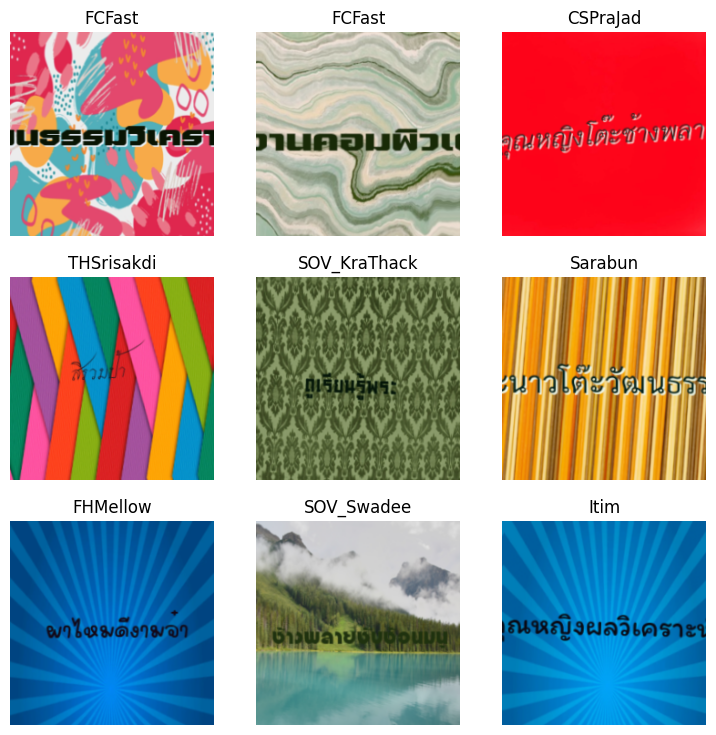

In [5]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda p: sampled_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='val'),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(
        mult=1.2,
        max_rotate=3.0,
        max_zoom=1.05,
        max_lighting=0.2,
        max_warp=0.0,
        do_flip=False,
    )
).dataloaders(path, bs=64, num_workers=4)

dls.show_batch(max_n=9)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 166MB/s]


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,5.685361,4.905324,0.041162,0.034509,50:06
1,4.605305,3.980635,0.126628,0.106352,04:01
2,3.829746,3.352875,0.200868,0.181137,04:02
3,3.429650,3.053830,0.242329,0.225025,04:01
4,3.306318,2.981791,0.260290,0.241106,03:59


<div></div>

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,3.291472,2.951250,0.262685,0.244888,04:23
1,3.258955,2.926039,0.271666,0.253041,04:14
2,3.204324,2.926019,0.263583,0.248006,04:10
3,3.162596,2.843553,0.281245,0.266051,04:16
4,3.081905,2.737877,0.296662,0.283157,04:12
5,2.970714,2.668111,0.309834,0.297884,04:04
6,2.899047,2.567849,0.332435,0.322968,04:05
7,2.693318,2.419117,0.364766,0.357744,04:09
8,2.617374,2.313787,0.379734,0.370956,04:07
9,2.476411,2.215509,0.395001,0.389035,04:05


Better model found at epoch 0 with valid_loss value: 2.951249837875366.
Better model found at epoch 1 with valid_loss value: 2.926039457321167.
Better model found at epoch 2 with valid_loss value: 2.9260191917419434.
Better model found at epoch 3 with valid_loss value: 2.843553304672241.
Better model found at epoch 4 with valid_loss value: 2.7378766536712646.
Better model found at epoch 5 with valid_loss value: 2.6681106090545654.
Better model found at epoch 6 with valid_loss value: 2.5678491592407227.
Better model found at epoch 7 with valid_loss value: 2.419116973876953.
Better model found at epoch 8 with valid_loss value: 2.3137872219085693.
Better model found at epoch 9 with valid_loss value: 2.2155086994171143.
Better model found at epoch 10 with valid_loss value: 2.113152265548706.
Better model found at epoch 11 with valid_loss value: 2.0095016956329346.
Better model found at epoch 12 with valid_loss value: 1.9359506368637085.
Better model found at epoch 13 with valid_loss value:

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


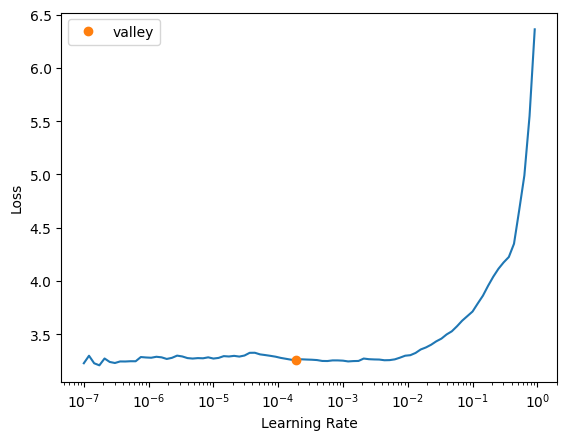

In [6]:
learn = vision_learner(
    dls, efficientnet_b3,
    metrics=[accuracy, F1Score(average='weighted')],
    ps=0.3,
).to_fp16()

learn.freeze()
learn.fit_one_cycle(5, 3e-4, wd=0.01)

learn.lr_find()

learn.unfreeze()
learn.fit_one_cycle(
    35,
    lr_max=slice(1e-6, 1e-4),
    wd=0.01,
    cbs=[
        SaveModelCallback(monitor='valid_loss', fname='best_model'),
        EarlyStoppingCallback(monitor='valid_loss', patience=5),
    ]
)

learn.load('best_model')

In [7]:
learn.load('best_model')

learn.fit_one_cycle(
    10,
    lr_max=slice(1e-7, 3e-5),
    wd=0.02,
    cbs=[
        SaveModelCallback(monitor='valid_loss', fname='best_model'),
        EarlyStoppingCallback(monitor='valid_loss', patience=4),
    ]
)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,1.524615,1.443669,0.571920,0.566482,04:13
1,1.530575,1.455561,0.572369,0.568850,04:17
2,1.567367,1.425145,0.577159,0.574195,04:09
3,1.540993,1.458302,0.571471,0.568322,04:10
4,1.554569,1.444355,0.569675,0.567112,04:12
5,1.500188,1.412019,0.581500,0.578940,04:10
6,1.535054,1.480975,0.566083,0.564031,04:07
7,1.480465,1.423967,0.578357,0.576006,04:09
8,1.516464,1.440261,0.572220,0.568896,04:09
9,1.484967,1.420845,0.578656,0.574422,04:07


Better model found at epoch 0 with valid_loss value: 1.4436691999435425.
Better model found at epoch 2 with valid_loss value: 1.4251450300216675.
Better model found at epoch 5 with valid_loss value: 1.4120194911956787.
No improvement since epoch 5: early stopping


In [8]:
save_path = Path('/content/drive/MyDrive')

learn.load('best_model')
learn.export(save_path/'font_classification_model.pkl')
print("Finish")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


บันทึกโมเดลเรียบร้อย


In [9]:
test_files = get_image_files(path/'test')
test_dl = dls.test_dl(test_files, with_labels=True)
test_metrics = learn.validate(dl=test_dl)

preds_probs, targs = learn.get_preds(dl=test_dl)
preds_decoded = preds_probs.argmax(dim=1)

from sklearn.metrics import recall_score, precision_score, classification_report
print(f"Accuracy  : {test_metrics[1]:.4f}")
print(f"Recall    : {recall_score(targs, preds_decoded, average='weighted', zero_division=0):.4f}")
print(f"Precision : {precision_score(targs, preds_decoded, average='weighted', zero_division=0):.4f}")
print(classification_report(targs, preds_decoded, target_names=dls.vocab, zero_division=0))

Accuracy  : 0.5843
Recall    : 0.5843
Precision : 0.5955
                             precision    recall  f1-score   support

        304PANITangCampDemo       0.47      0.39      0.42        36
          305PANITheFoxDemo       0.67      0.61      0.64        36
          388PANIDekDeuDemo       0.68      0.53      0.59        36
         390PANIDoenPaaDemo       0.64      0.58      0.61        36
                    Arabica       0.70      0.64      0.67        36
                     Athiti       0.44      0.44      0.44        36
                BTN-Somboon       0.46      0.53      0.49        36
                BaiJamjuree       0.30      0.22      0.25        36
                       Boon       0.31      0.39      0.35        36
                 CSChatThai       0.12      0.08      0.10        36
                   CSPraJad       0.78      0.78      0.78        36
                   CSPraKas       0.28      0.25      0.26        36
                ChakraPetch       0.26      0

[('SOV_KraThack', 'SOV_MumMong', np.int64(16)),
 ('FC Issara Rounded', 'FC Vision Rounded', np.int64(13)),
 ('SOV_MumMong', 'SOV_KraThack', np.int64(13)),
 ('Athiti', 'Cloud', np.int64(12)),
 ('FC Vision Wide', 'FCEXP', np.int64(12)),
 ('MN Nang Kai Thot', 'MN Anago', np.int64(12)),
 ('FCVision', 'FC Vision Wide', np.int64(11)),
 ('PGWendy', 'FHMellow', np.int64(11)),
 ('THBaijam', 'THNiramit AS', np.int64(11)),
 ('CSPraKas', 'Fahkwang', np.int64(10)),
 ('BTN-Somboon', 'MN Yam Wunsen', np.int64(9)),
 ('FC Issara', 'Mitr', np.int64(9)),
 ('FC Sara Samkan', 'Taviraj', np.int64(9)),
 ('FC Vision Wide', 'FCMittraphap', np.int64(9)),
 ('FCPride', 'Mitr', np.int64(9)),
 ('FCVision', 'FCMittraphap', np.int64(9)),
 ('K2D', 'Krub', np.int64(9)),
 ('KhwanThong', 'JS Junkaew', np.int64(9)),
 ('Taviraj', 'Fahkwang', np.int64(9)),
 ('BaiJamjuree', 'ChakraPetch', np.int64(8)),
 ('FCPride', 'Kanit', np.int64(8)),
 ('FkCider', 'Mali', np.int64(8)),
 ('NotoSansThai', 'Sukhumvit', np.int64(8)),
 ('Promp

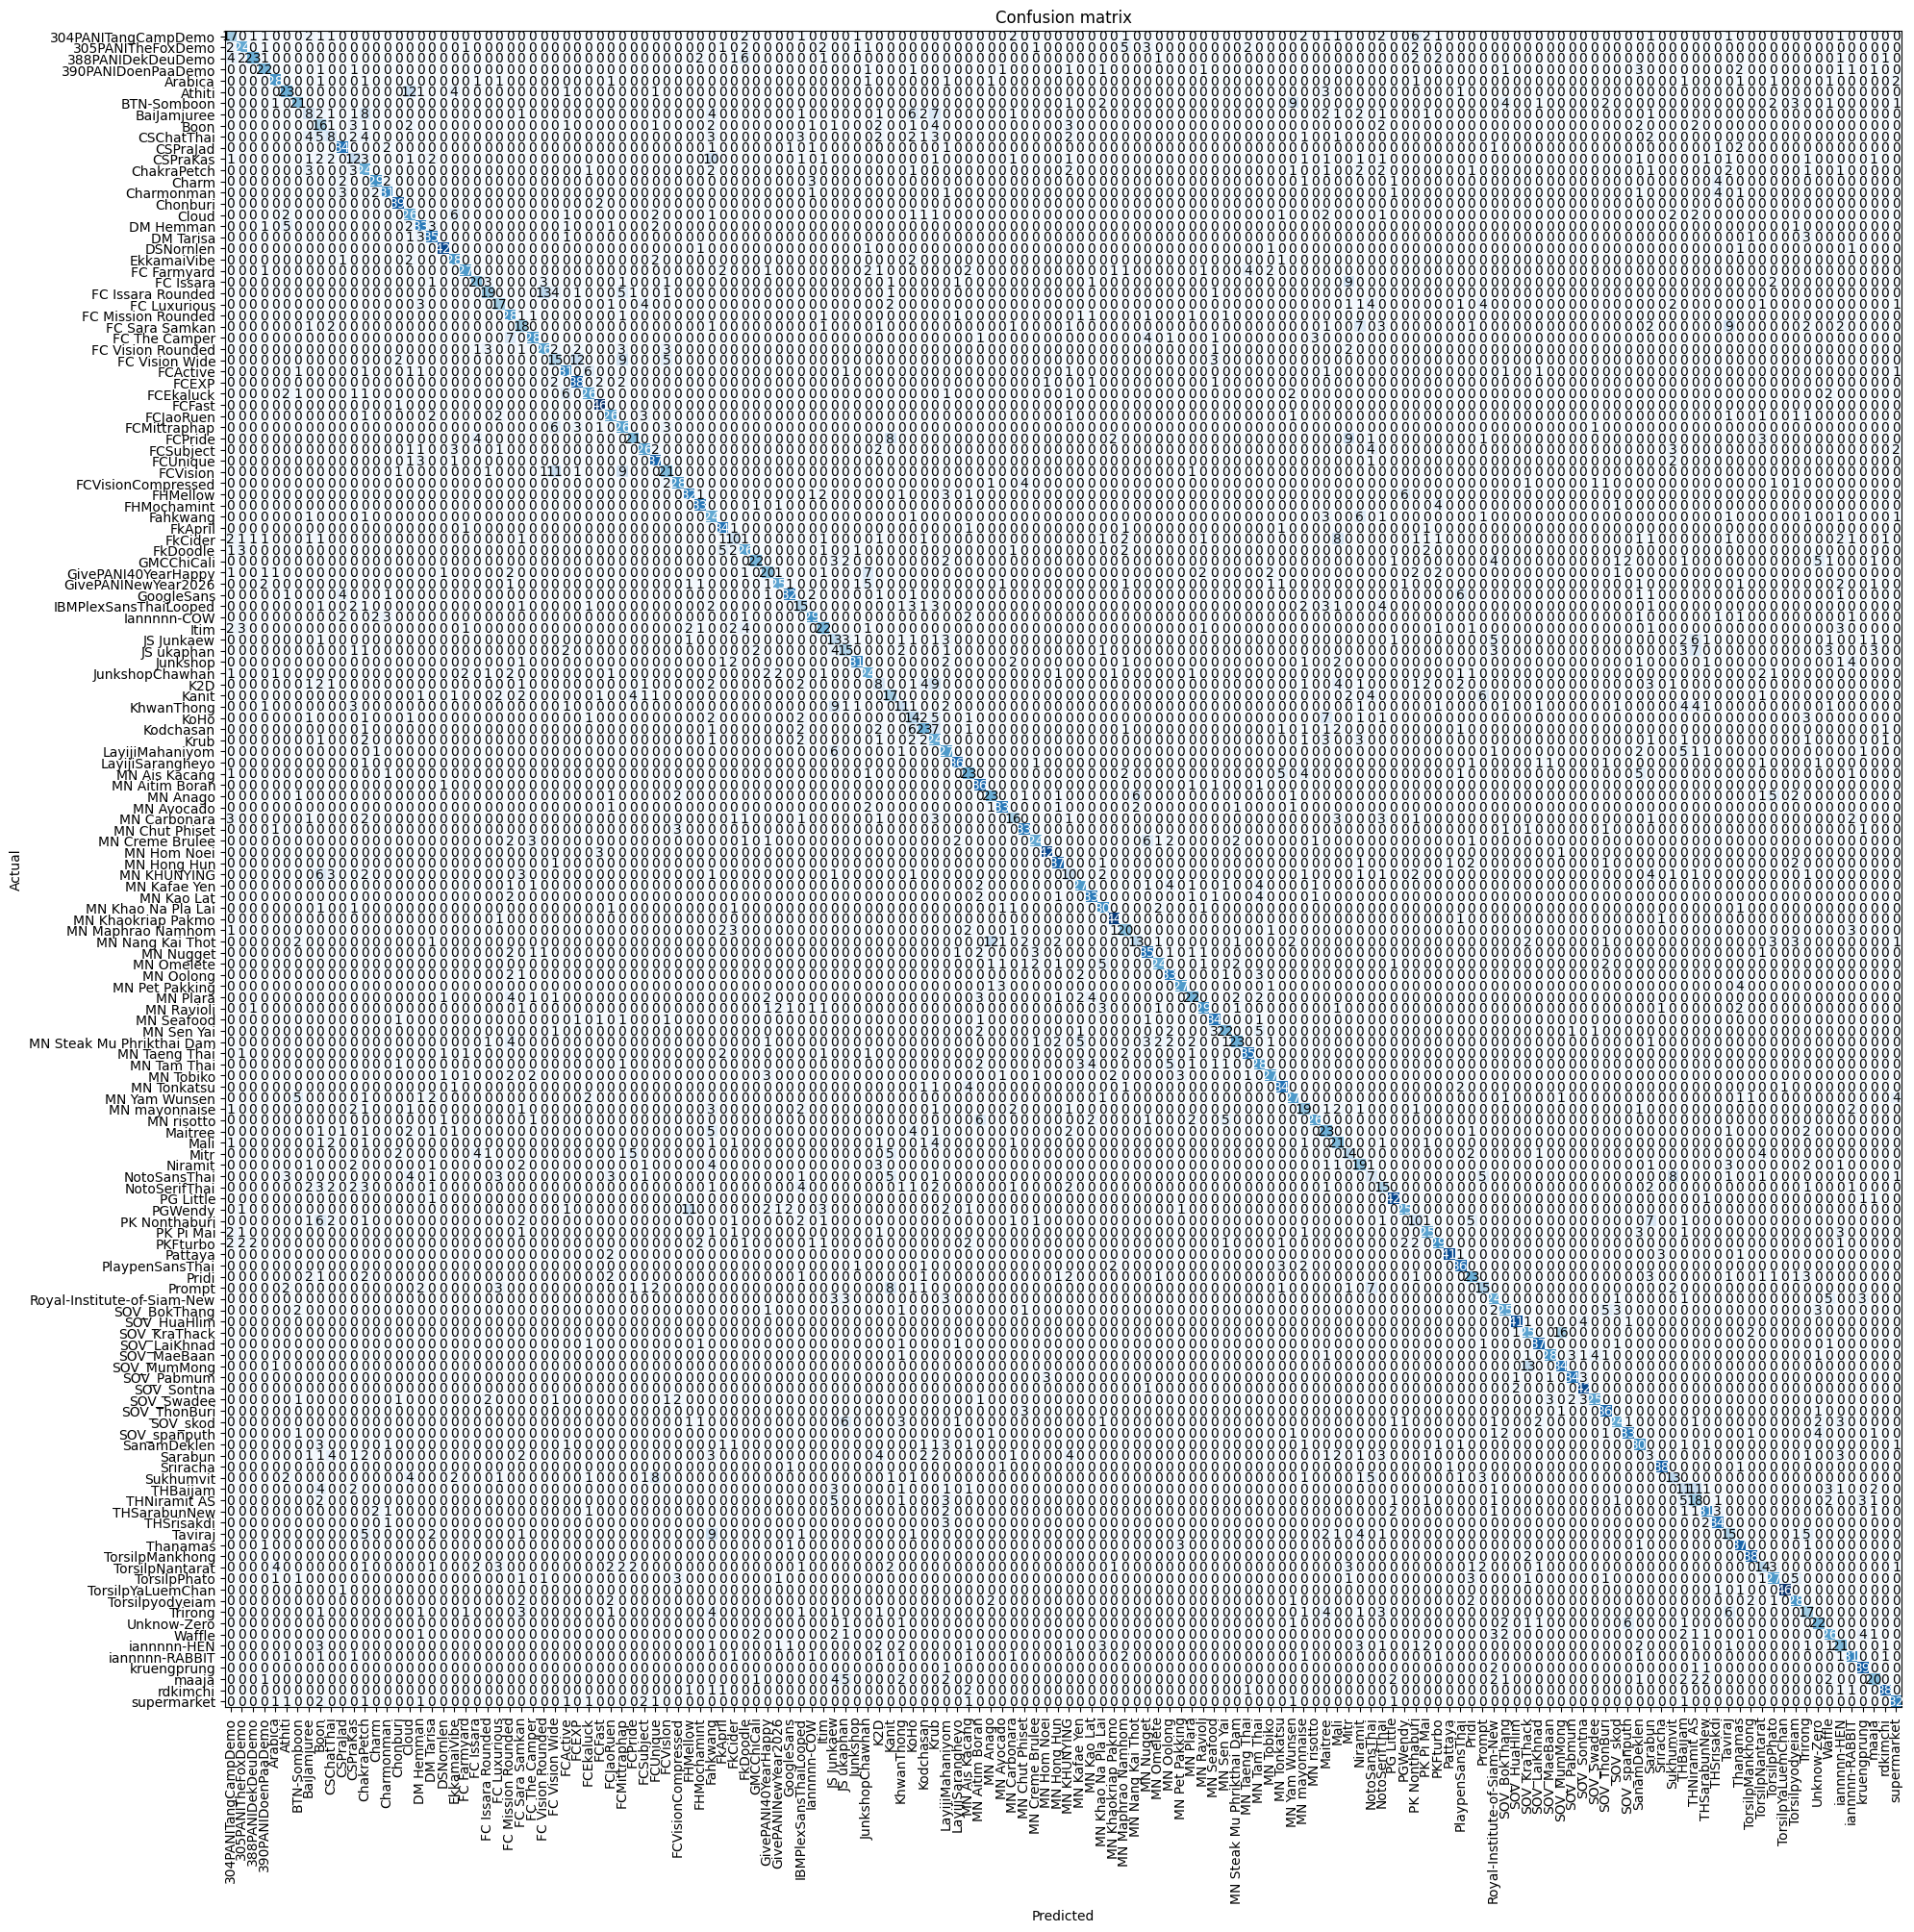

In [10]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(20, 20))
interp.most_confused(min_val=5)  # ดูคู่ที่สับสนที่สุด

In [28]:
learn.export()
learn.export('/content/model.pkl')
